# Asignación 3 — Ingeniería de Características

**Alumno:** Víctor Manuel Santos Martínez  
**Materia:** Aprendizaje Automático No Supervisado  
**Objetivo:** Construir dos nuevas características a partir del dataset de entretenimiento estudiantil:
- `total_entertainment`: horas totales de entretenimiento por semana por estudiante.
- `pct_screen`: porcentaje del entretenimiento consumido a través de pantallas (todo excepto libros).

## 1. Importaciones

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Constantes de dominio
DATASET_PATH = 'entertainment.xlsx'
SCREEN_TYPES = {'video_games', 'tv_shows', 'movies'}  # todo excepto libros


## 2. Carga del dataset

El dataset está en formato **largo** (*long format*): cada fila representa un tipo de entretenimiento para un estudiante. Antes de construir las nuevas columnas es necesario entender la estructura original.

In [2]:
df_long = pd.read_excel(DATASET_PATH)
print(f'Dimensiones: {df_long.shape}')
print(f'Columnas: {df_long.columns.tolist()}')
df_long.head(8)

Dimensiones: (600, 3)
Columnas: ['name', 'entertainment', 'hours_per_week']


,name,entertainment,hours_per_week
0,Emily,video_games,5.1
1,Liam,video_games,4.9
2,Olivia,video_games,4.7
3,Noah,video_games,4.6
4,Ava,video_games,5.0
5,Isabella,video_games,5.4
6,Sophia,video_games,4.6
7,Mia,video_games,5.0


### 2.1 Valores únicos y nulos

In [3]:
print('Tipos de entretenimiento:', df_long['entertainment'].unique())
print(f'\nEstudiantes únicos: {df_long["name"].nunique()}')
print(f'\nValores nulos:\n{df_long.isnull().sum()}')

Tipos de entretenimiento: <StringArray>
['video_games', 'tv_shows', 'movies', 'books']
Length: 4, dtype: str

Estudiantes únicos: 150

Valores nulos:
name              0
entertainment     0
hours_per_week    5
dtype: int64


## 3. Transformación: formato largo a ancho

Para calcular métricas por estudiante se pivota el dataframe de modo que cada tipo de entretenimiento quede como una columna separada. Los 5 valores nulos en `hours_per_week` se rellenan con `0` (el estudiante no reportó horas → se asume ausencia de consumo).

In [4]:
df_wide = (
    df_long
    .pivot_table(index='name', columns='entertainment', values='hours_per_week')
    .fillna(0)
    .reset_index()
)
df_wide.columns.name = None
print(f'Dimensiones (ancho): {df_wide.shape}')
df_wide.head()

Dimensiones (ancho): (150, 5)


,name,books,movies,tv_shows,video_games
0,Aaliyah,0.5,1.5,4.6,4.9
1,Abigail,0.0,1.4,4.5,4.8
2,Addison,0.5,1.6,4.5,5.0
3,Adeline,3.5,4.4,4.5,6.6
4,Alana,2.8,3.9,3.8,5.6


## 4. Ingeniería de características

### 4.1 `total_entertainment`
Suma las horas semanales de todos los tipos de entretenimiento por estudiante.

In [5]:
entertainment_cols = [c for c in df_wide.columns if c != 'name']
df_wide['total_entertainment'] = df_wide[entertainment_cols].sum(axis=1)
print('Estadísticas de total_entertainment:')
df_wide['total_entertainment'].describe()

Estadísticas de total_entertainment:


count    150.000000
mean      17.180667
std        4.190781
min        9.900000
25%       12.925000
50%       17.550000
75%       20.150000
max       25.600000
Name: total_entertainment, dtype: float64

### 4.2 `pct_screen`
Calcula el porcentaje de horas consumidas en pantallas (videojuegos, series y películas) respecto al total.

$$\text{pct\_screen} = \frac{\sum_{\text{screen}}\text{horas}}{\text{total\_entertainment}} \times 100$$

Cuando `total_entertainment == 0` el resultado se fija en `0` para evitar división por cero.

In [6]:
screen_cols = [c for c in entertainment_cols if c in SCREEN_TYPES]
screen_hours = df_wide[screen_cols].sum(axis=1)

df_wide['pct_screen'] = (
    screen_hours
    .div(df_wide['total_entertainment'])
    .mul(100)
    .fillna(0)
    .round(2)
)
print('Estadísticas de pct_screen:')
df_wide['pct_screen'].describe()

Estadísticas de pct_screen:


count    150.000000
mean      84.380800
std        8.169538
min       71.560000
25%       78.370000
50%       81.595000
75%       93.445000
max      100.000000
Name: pct_screen, dtype: float64

## 5. Resultado final

In [7]:
print(f'Dataset final: {df_wide.shape}')
df_wide[['name', 'books', 'movies', 'tv_shows', 'video_games',
          'total_entertainment', 'pct_screen']].head(10)

Dataset final: (150, 7)


,name,books,movies,tv_shows,video_games,total_entertainment,pct_screen
0,Aaliyah,0.5,1.5,4.6,4.9,11.5,95.65
1,Abigail,0.0,1.4,4.5,4.8,10.7,100.00
2,Addison,0.5,1.6,4.5,5.0,11.6,95.69
3,Adeline,3.5,4.4,4.5,6.6,19.0,81.58
4,Alana,2.8,3.9,3.8,5.6,16.1,82.61
5,Alexander,5.8,5.1,4.6,6.9,22.4,74.11
6,Alivia,4.2,5.0,4.5,6.7,20.4,79.41
7,Amara,3.2,4.1,4.5,5.6,17.4,81.61
8,Amelia,0.0,1.5,4.6,4.9,11.0,100.00
9,Annabelle,4.0,5.1,4.1,6.0,19.2,79.17


## 6. Visualizaciones

### 6.1 Distribución de `total_entertainment`

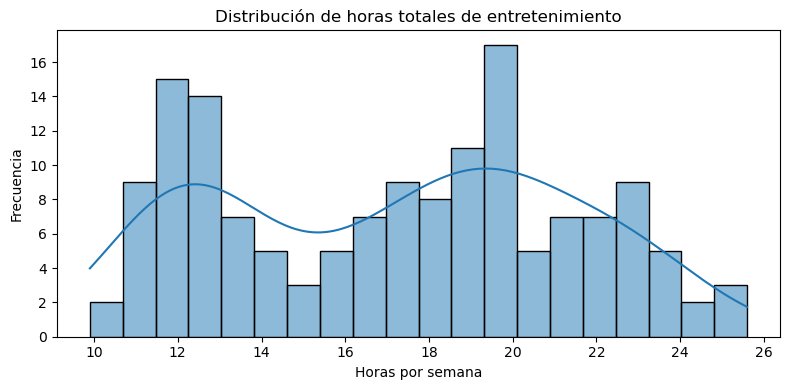

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_wide['total_entertainment'], bins=20, kde=True, ax=ax)
ax.set_title('Distribución de horas totales de entretenimiento')
ax.set_xlabel('Horas por semana')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('fig_total_entertainment.png', dpi=150)
plt.show()

### 6.2 Distribución de `pct_screen`

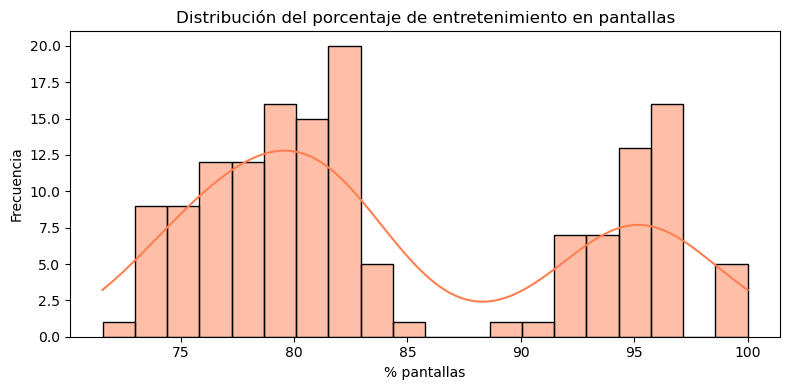

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_wide['pct_screen'], bins=20, kde=True, color='coral', ax=ax)
ax.set_title('Distribución del porcentaje de entretenimiento en pantallas')
ax.set_xlabel('% pantallas')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('fig_pct_screen.png', dpi=150)
plt.show()

### 6.3 Horas promedio por tipo de entretenimiento

/tmp/ipykernel_86011/3281269854.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_by_type, x='tipo', y='horas_promedio', palette='Set2', ax=ax)


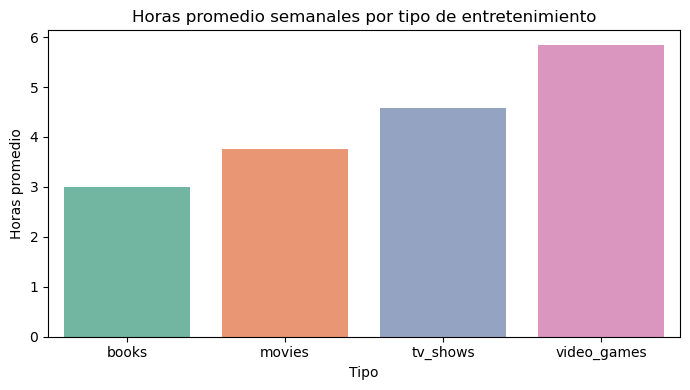

In [10]:
avg_by_type = df_wide[entertainment_cols].mean().reset_index()
avg_by_type.columns = ['tipo', 'horas_promedio']

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=avg_by_type, x='tipo', y='horas_promedio', palette='Set2', ax=ax)
ax.set_title('Horas promedio semanales por tipo de entretenimiento')
ax.set_xlabel('Tipo')
ax.set_ylabel('Horas promedio')
plt.tight_layout()
plt.savefig('fig_avg_by_type.png', dpi=150)
plt.show()

### 6.4 Relación entre `total_entertainment` y `pct_screen`

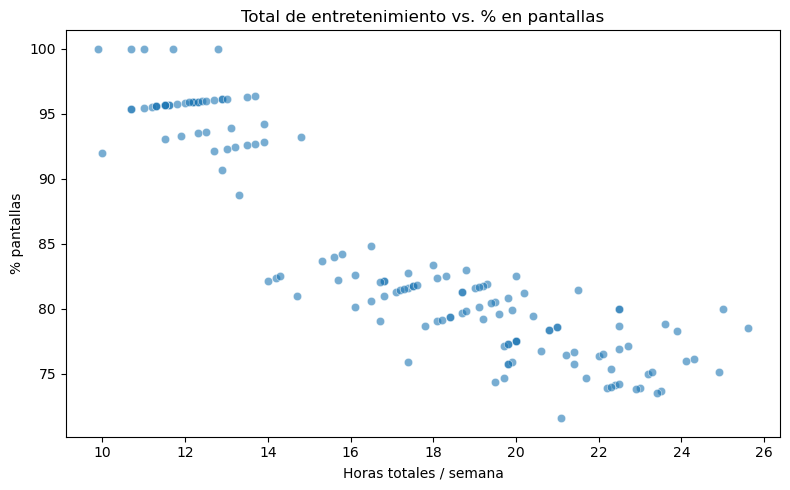

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_wide, x='total_entertainment', y='pct_screen',
                alpha=0.6, ax=ax)
ax.set_title('Total de entretenimiento vs. % en pantallas')
ax.set_xlabel('Horas totales / semana')
ax.set_ylabel('% pantallas')
plt.tight_layout()
plt.savefig('fig_scatter.png', dpi=150)
plt.show()

## 7. Exportar resultado

In [12]:
output_path = 'entertainment_features.csv'
df_wide.to_csv(output_path, index=False)
print(f'Dataset exportado a: {output_path}')

Dataset exportado a: entertainment_features.csv
